<a href="https://colab.research.google.com/github/Laragb21/PRA3024_BigDataPhysics/blob/main/ML_cifar_CNN_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#(28,28,1)--> (26,26,10) cernels
#max pooling
#color pictures are 3D
#to flatten the pictures and do it like in part 1 also works, but the predictions will be worse

In [3]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file): #returns a dictionary with data and labels example keys in CIFAR-10: "data" (images) and "labels" (integers 0–9 representing classes).
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict

def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)
#np.concatenate combines two arrays in an axis
    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

Cifar-10 is a dataset for machine-learing. It contains 60 000 images a 32x32 resolution in 10 different classes (e.g.dogs, airplanes etc.).
It has 50 000 training and 10 000 test images.

In [4]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [5]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


In [6]:
print(y_train)

[6 4 1 ... 2 5 6]


After loading the data, we can confim that the cifar10 data set contains 60 000 data points in total, where 40000 images are used for training the model (train samples), 10000 images are test images, which are only used for the final test (the images are not used for training) , and the remaining 10000 images are validation images. Those are used to check how far the model has developed.

Furthermore, the x shape of the samples is 32x32 pixels in 3 dimensions, because the pictures are colored.

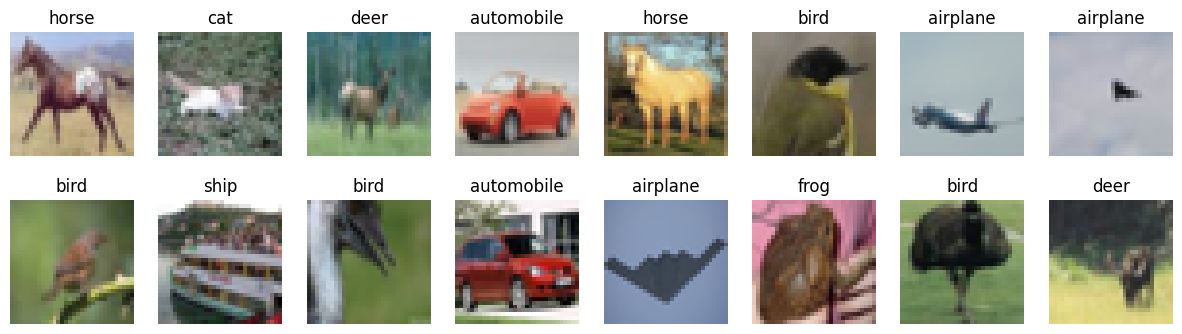

In [7]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train)) #randit= picks a random number in the given interval
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]]) #random index in y_train matches the true label to the randomly chosen pictures
plt.show()

Here 16 random pictures from the training data set are loaded with their true label. Randit picks a random number in the given interval (0-40000).

In [8]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
#x_train = x_train.astype(np.float64) - 0.5
from tensorflow.keras.utils import to_categorical

#keras.utils --> coverts integers into one-hot encoded vectors [0,0,0,0,1,0,...]

y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_val = keras.utils.to_categorical(y_val, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(40000, 10)
(10000, 10)
(10000, 10)


In [9]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.layers import LeakyReLU

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Activation, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def make_model():
    model = Sequential() #staples the layers

    # Block 1: conv-relu-conv-relu-pool
    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3))) #32 kernels a 3x3 pixels
    model.add(Activation('relu')) #recfified linear unit, only lets positive signals through
    model.add(Conv2D(32, (3,3), padding='same')) #32x32 spatial size (large images and few filters)
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(BatchNormalization())

    # Block 2: conv-relu-conv-relu-pool
    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(64, (3,3), padding='same')) #smaller images and more filters 64 different kernels
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Block 3: conv-relu-conv-relu-pool (deeper for better features)
    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(128, (3,3), padding='same')) #128 different kernels
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Block 4: conv-relu-conv-relu-pool (deeper for better features)
    model.add(Conv2D(256, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(256, (3,3), padding='same')) #256 different kernels
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    model.add(Flatten()) #flattens the data to a 1D-vector for the dense function
    model.add(Dense(512, activation='relu')) #combines all the learned features for the final classification
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model


Here the machine-learning module is defined. Instead of flattening the data like in the exercise set before, the module is build as a convolutional neural network, so that 3D (colored pictures) can be analysed most accurately. Like in the Lecture CNN example (Slide 33), the model layers are based on conv, relu,conv,relu, pooling pattern.
Each of my blocks follows the same patter, two Conv2 layers, which scan the image using small 3x3 kernels, which are grids of learned weights, for identifying edges in the image. In the first layers simple features are picked up, while in the later layers (e.g.128 or 256 filter) complex concepts/identifications are made. This is done by applying double the filters as the previous layer. In the first layer there are 32 different kernels, then 64 --> 128 --> 256. After each convolution, RELU is activated, which gets rid of all negative values to keep the network non-linear. MaxPooling halves the image size by only keeping the strongest signal from each block and BatchNormalization normalizes the scale. The Dropout function switches off neurons in training, so that the do not just memorize data, but actually learn it.

In [11]:

### --> change the parameters below to perform a better training
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
INIT_LR = 5e-3  # initial learning rate
BATCH_SIZE = 32
EPOCHS = 10

K.clear_session()  # clear default graph
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model

# prepare model for fitting (loss, optimizer, etc)
model.compile(
    loss='categorical_crossentropy',  # we train 10-way classification
    optimizer=keras.optimizers.Adamax(learning_rate=INIT_LR),  # for SGD.
    metrics=['accuracy']  # report accuracy during training
)

# fit model

model.fit(
    x_train, y_train,  # prepared data
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True,
)

# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.2957 - loss: 2.0887 - val_accuracy: 0.3890 - val_loss: 2.0032
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5220 - loss: 1.3355 - val_accuracy: 0.4141 - val_loss: 2.3747
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6392 - loss: 1.0403 - val_accuracy: 0.6636 - val_loss: 0.9762
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7030 - loss: 0.8652 - val_accuracy: 0.6500 - val_loss: 1.0061
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7516 - loss: 0.7281 - val_accuracy: 0.7533 - val_loss: 0.7195
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7829 - loss: 0.6401 - val_accuracy: 0.7651 - val_loss: 0.7172
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8066 - loss: 0.5650 - val_accuracy: 0.7900 - val_loss: 0.6169
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8248 - loss: 

In [12]:
print("x_train:", x_train.shape)   # (num_samples, 32, 32, 3)
print("y_train:", y_train.shape)   # (num_samples, 10)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)

x_train: (40000, 32, 32, 3)
y_train: (40000, 10)
x_val: (10000, 32, 32, 3)
y_val: (10000, 10)


checking the shape of the  samples. The x data (cifar images) should have 3 dimensions (#images, 32, 32, 3) while the y data should only have two dimensions (#images, 10) so they match the output, certain label.

In [13]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")
print("Loaded weights from file.")

Loaded weights from file.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


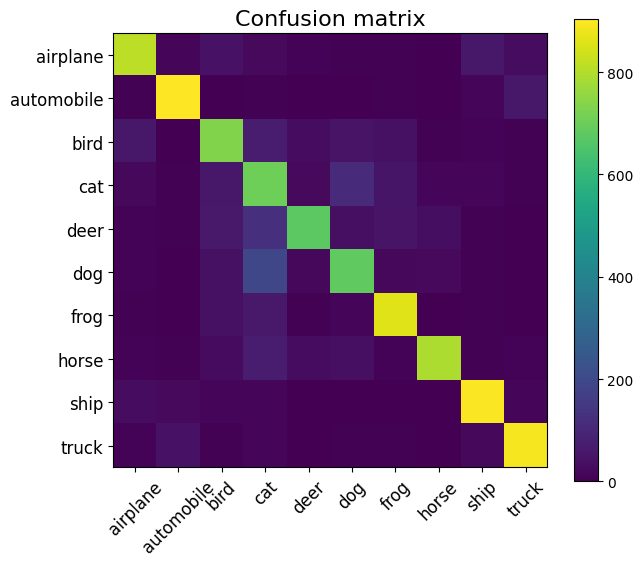

Test accuracy: 0.7953


In [14]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

A test accuracy of 0.7953 was achived with the model build. I could see that the accuracy went up, as soon as I started adding more layers to the model. The confusion matrix shows, that most confidently, an automobile, ship and truck could be identified. The rather challenging identification images are the ones depicting dogs, deers and cats.

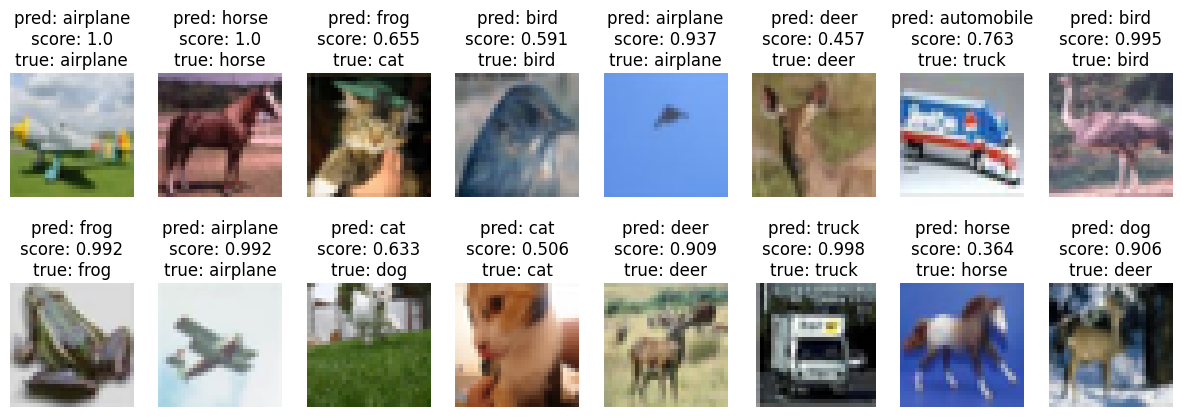

In [15]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.


